In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from gammapy.modeling.models import SkyModel, NaimaSpectralModel

from astropy.table import Table
import astropy.units as u
from gammapy.estimators import FluxPoints
from gammapy.modeling.models import NaimaSpectralModel, PowerLawSpectralModel
from naima.models import ExponentialCutoffPowerLaw, InverseCompton

from scipy.optimize import curve_fit
from utils import *
from gammapy.catalog import CATALOG_REGISTRY
from gammapy.datasets import FluxPointsDataset
from gammapy.modeling import Fit
from naima.models import PowerLaw, PionDecay
import yaml

import os

os.environ["GAMMAPY_DATA"] = "/Users/adminlocal/Documents/gammapy-datasets/2.0" #gammapy download datasets
#for info https://docs.gammapy.org/2.0.1/getting-started/index.html
SOURCE_NAME = "Westerlund1"

<Axes: xlabel='Energy [$\\mathrm{TeV}$]', ylabel='e2dnde [$\\mathrm{erg\\,s^{-1}\\,cm^{-2}}$]'>

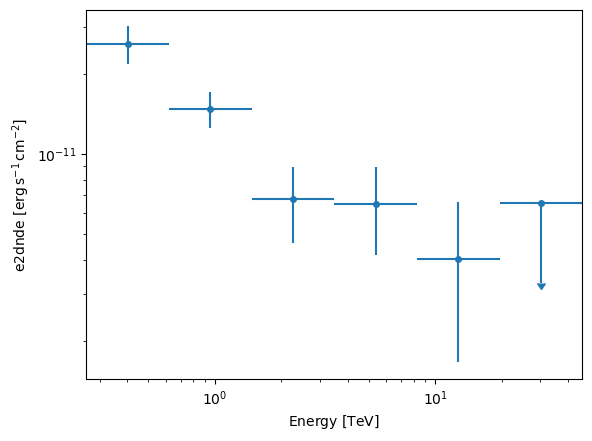

In [2]:
hgps = CATALOG_REGISTRY.get_cls("hgps")()# retrieve HESS catalogue HGPS (H.E.S.S. Galactic Plane Survey)
w1 = SkyCoord.from_name("Westerlund 1") # astropy --> Westerlund coordinates 

mask = w1.separation(hgps.positions)<1*u.deg
hgps_westerlund = hgps[mask][0]
hgps_westerlund.flux_points.plot(sed_type="e2dnde")

In [3]:
print(hgps_westerlund.info()) # everything handles inside, without needed to search for data-points!



*** Basic info ***

Catalog row index (zero-based) : 0
Source name          : HESS J1646-458
Analysis reference   : HGPS
Source class         : Unid
Identified object    : --
Gamma-Cat id         : 90


*** Info from map analysis ***

RA                   :  251.979 deg = 16h47m55s
DEC                  :  -46.258 deg = -46d15m30s
GLON                 :  339.334 +/- 0.040 deg
GLAT                 :   -0.780 +/- 0.044 deg
Position Error (68%) : 0.091 deg
Position Error (95%) : 0.147 deg
ROI number           : 11
Spatial model        : Gaussian
Spatial components   : HGPSC 038
TS                   : 346.4
sqrt(TS)             : 18.6
Size                 : 0.503 +/- 0.030 (UL: 0.000) deg
R70                  : 0.785 deg
RSpec                : 0.500 deg
Total model excess   : 2532.7
Excess in RSpec      : 1067.4
Model Excess in RSpec : 1055.2
Background in RSpec  : 4757.6
Livetime             : 68.3 hours
Energy threshold     : 0.44 TeV
Source flux (>1 TeV) : (5.481 +/- 0.455) x 10^-12 cm^

/opt/anaconda3/envs/gammapy-acme/lib/python3.12/site-packages/gammapy/catalog/hess.py:287: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  ss += "{:<20s} : {:.1f}\n".format("TS ECPL over PL", val)
/opt/anaconda3/envs/gammapy-acme/lib/python3.12/site-packages/gammapy/catalog/hess.py:377: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  ss += "{:<20s} : {:.2f} +/- {:.2f}\n".format("ECPL Index", val, err)
/opt/anaconda3/envs/gammapy-acme/lib/python3.12/site-packages/gammapy/catalog/hess.py:385: RuntimeWarning: invalid value encountered in scalar divide
  err = err / val**2
/opt/anaconda3/envs/gammapy-acme/lib/python3.12/site-packages/gammapy/catalog/hess.py:386: RuntimeWarning: divide by zero encountered in scalar divide
  val = 1.0 / val


In [4]:
fp = FluxPointsDataset(data=hgps_westerlund.flux_points, name="hgps") #https://docs.gammapy.org/2.0.1/api/gammapy.datasets.FluxPointsDataset.html


In [5]:
model = SkyModel.create(spectral_model="ecpl") # what if I want to change the functional shape?

| Alias    | Model                                 |
| -------- | ------------------------------------- |
| `"pl"`   | `PowerLawSpectralModel`               |
| `"ecpl"` | `ExpCutoffPowerLawSpectralModel`      |
| `"lp"`   | `LogParabolaSpectralModel`            |
| `"pl2"`  | `PowerLaw2SpectralModel`              |
| `"elp"`  | `SuperExpCutoffPowerLawSpectralModel` |


In [6]:
fp.models = model

In [7]:
result = Fit().run([fp])

In [8]:
print(result)

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 192
	total stat : 0.78

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.



In [9]:
result.models

(<Axes: xlabel='Energy [$\\mathrm{TeV}$]', ylabel='e2dnde [$\\mathrm{erg\\,s^{-1}\\,cm^{-2}}$]'>,
 <Axes: xlabel='Energy [$\\mathrm{TeV}$]', ylabel='Residuals\n (data - model) / model'>)

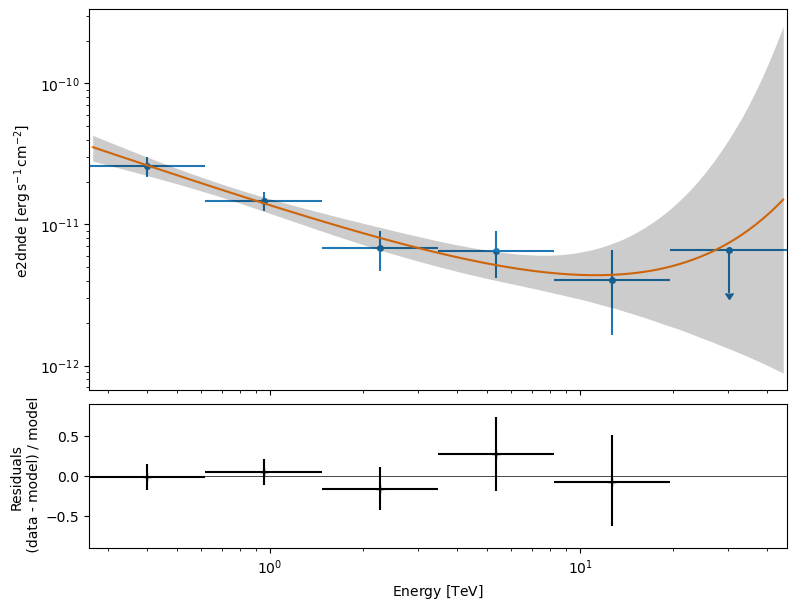

In [10]:
fp.plot_fit()

In [19]:
source_dist = 4.0 * u.kpc
proton_pl = ExponentialCutoffPowerLaw(
    amplitude=1e35 / u.eV,
    e_0=10 * u.TeV,
    alpha=2.0,
    e_cutoff=90 * u.TeV,   
    beta=1.0               
)
naima_model = NaimaSpectralModel(PionDecayKelner06(proton_pl, particle_type='gamma'), distance=source_dist)

naima_model.e_0.frozen=True
model = SkyModel(spectral_model=naima_model)
fp.models = [model]
results = Fit().run([fp])
pars = results.models[0].spectral_model

proton_params = {
    "amplitude": float(pars.amplitude.value),
    "alpha": float(pars.alpha.value),
    "e_0": float(pars.e_0.value),
    "e_cutoff": float(pars.e_cutoff.value),
    "beta": float(pars.beta.value),
}

with open(f"{SOURCE_NAME}_model.yaml", "w") as f:
    yaml.safe_dump(proton_params, f)

results.models


In [20]:
nu_model = NaimaSpectralModel(
    PionDecayKelner06(proton_pl, particle_type="muon_neutrino", oscillation_factor=0.5),
    distance=source_dist,
)

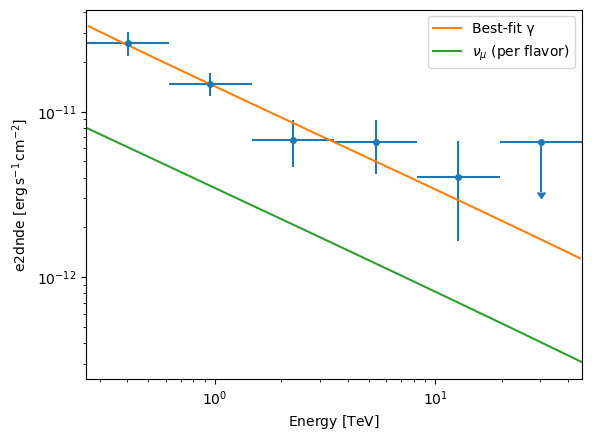

In [21]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

w1 = SkyCoord.from_name("Westerlund 1")
mask = w1.separation(hgps.positions) < 1 * u.deg
hgps_westerlund = hgps[mask][0]

emin = hgps_westerlund.flux_points.energy_min.min()
emax = hgps_westerlund.flux_points.energy_max.max()
E = np.geomspace(emin.to_value("TeV"), emax.to_value("TeV"), 200) * u.TeV

ax = hgps_westerlund.flux_points.plot(sed_type="e2dnde")

gamma_model = fp.models[0].spectral_model
gamma_model.plot(
    ax=ax,
    energy_bounds=[emin, emax],
    sed_type="e2dnde",
    label="Best-fit γ",
)

e2dnde_nu = (E**2 * nu_model(E)).to("TeV cm-2 s-1")
ax.plot(E, e2dnde_nu, label=r"$\nu_\mu$ (per flavor)")

ax.legend()
plt.show()



What happenend if we change functional shape?

What if all the gamma are not produced by Pion decay?

##  Comparing Gammapy ECPL vs Naima ECPL

There are two commonly used exponential–cutoff power-law models:

---

### **1. Gammapy: `ExpCutoffPowerLawSpectralModel` ("ecpl")**

Mathematical form:

$$
\phi(E) = \phi_0 \left( \frac{E}{E_0} \right)^{-{\rm index}}
\exp\left[-(\lambda E)^{\alpha_{\rm cut}}\right]
$$

Parameters:

- `amplitude` → flux normalization at `reference`
- `index` → spectral index  
- `lambda_` → cutoff parameter (units: 1 / energy)  
- `alpha` → cutoff exponent (usually fixed to 1)
- This model describes **observed photon flux** (e.g. TeV⁻¹ cm⁻² s⁻¹)

Cutoff energy is roughly related to `lambda_` by:

$$
E_{\rm cutoff} \approx \frac{1}{\lambda}
$$

---

### **2. Naima: `ExponentialCutoffPowerLaw`**

Mathematical form:

$$
N(E) = A \left( \frac{E}{E_0} \right)^{-\alpha}
\exp\left[-\left(\frac{E}{E_{\rm cutoff}}\right)^{\beta}\right]
$$

Parameters:

- `amplitude` → normalization of the **particle distribution** (dN/dE)
- `alpha` → spectral index
- `e_cutoff` → cutoff energy  
- `beta` → cutoff shape exponent  
- This model describes **particle spectra** (e.g. protons/electrons), not photon flux


### **Conclusion**

You cannot directly take Gammapy ECPL best-fit parameters and insert them into Naima ECPL:  
they describe different physical quantities and use different parameterizations.

To maintain physical consistency, fit the gamma-ray data using a **NaimaSpectralModel** inside Gammapy so that both gamma and neutrino spectra originate from the same underlying particle distribution.